In [1]:
# End to End project on ml (On classification problem)

In [2]:
import numpy as np
import pandas as pd
import sklearn

In [3]:
print('numpy',np.__version__)
print('pandas',pd.__version__)
print('sklearn',sklearn.__version__)

numpy 2.3.5
pandas 2.3.3
sklearn 1.8.0


In [4]:
df=pd.read_csv('placement.csv')

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
df=df.iloc[:,1:]

In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
import matplotlib.pyplot as plt

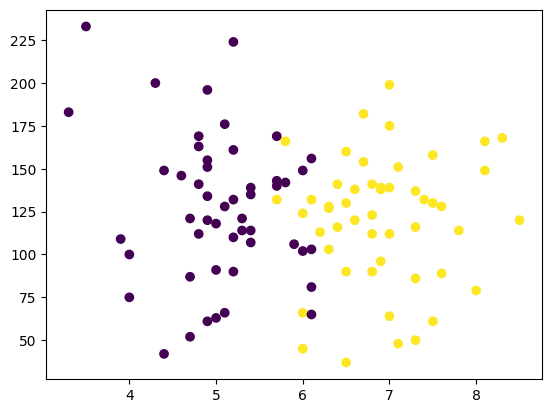

In [11]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
x=df.iloc[:,0:2]

In [13]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [14]:
y=df.iloc[:,-1]

In [15]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [16]:
x.shape

(100, 2)

In [17]:
y.shape

(100,)

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.1)

In [19]:
X_train

,cgpa,iq
5,7.1,48.0
40,4.9,134.0
12,5.4,139.0
13,6.4,116.0
84,5.7,169.0
...,...,...
36,5.7,140.0
62,6.0,102.0
28,5.2,90.0
93,6.8,112.0


In [20]:
Y_train

5     1
40    0
12    0
13    1
84    0
     ..
36    0
62    0
28    0
93    1
18    0
Name: placement, Length: 90, dtype: int64

In [21]:
from sklearn.preprocessing import StandardScaler


In [22]:
scaler=StandardScaler()

In [23]:
X_train=scaler.fit_transform(X_train)

In [24]:
X_train

array([[ 1.02342144, -1.81693611],
       [-0.89186632,  0.28642696],
       [-0.45657365,  0.40871551],
       [ 0.4140117 , -0.15381182],
       [-0.19539804,  1.14244682],
       [-0.71774925, -1.37669733],
       [ 0.93636291,  1.28919308],
       [-2.11068581,  2.70774026],
       [ 0.06577756, -1.89030924],
       [-1.327159  ,  0.65329261],
       [ 0.93636291,  1.87617812],
       [ 1.89400679,  0.65329261],
       [-0.63069072,  2.48762087],
       [-0.97892486,  0.99570055],
       [ 0.15283609, -0.47176205],
       [-0.45657365,  0.31088467],
       [ 1.37165558, -1.49898588],
       [-0.89186632,  0.70220803],
       [ 1.28459705,  0.23751154],
       [-0.63069072, -0.30055808],
       [-1.41421753,  1.90063583],
       [ 2.24224093, -0.05598098],
       [ 1.37165558,  0.873412  ],
       [-0.97892486,  0.45763093],
       [ 0.84930437, -0.64296602],
       [-1.15304193,  0.57991948],
       [-0.71774925,  0.1396807 ],
       [-1.06598339, -1.71910527],
       [-1.76245167,

In [25]:
X_test=scaler.transform(X_test)

In [26]:
X_test

array([[ 0.32695316,  0.1396807 ],
       [ 0.23989463, -0.22718495],
       [ 0.32695316,  0.11522299],
       [-0.80480779, -0.1048964 ],
       [ 2.06812386,  1.1179891 ],
       [ 0.6751873 ,  1.46039705],
       [ 0.50107023,  0.92232742],
       [ 0.76224584,  0.01739215],
       [ 1.37165558,  0.18859612],
       [ 0.32695316, -0.47176205]])

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
clf=LogisticRegression()

In [29]:
#model training
clf.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
Y_pred=clf.predict(X_test)  #prediction by model

In [31]:
Y_test    #given prediction in output col.

63    1
99    1
70    1
67    0
53    1
97    1
38    1
0     1
83    1
98    1
Name: placement, dtype: int64

In [32]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy_score(Y_test,Y_pred)

1.0

In [35]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

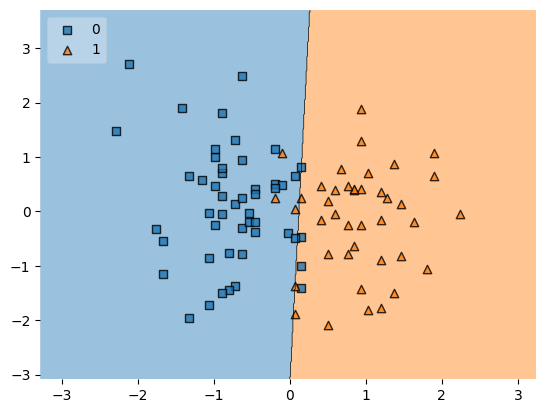

In [36]:
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2)

In [37]:
import pickle

In [38]:
pickle.dump(clf,open('model1.pkl','wb'))

In [42]:
import pickle

with open("model1.pkl", "rb") as file:
    model = pickle.load(file)

In [43]:
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [71]:
input_value = [[8, 100]]

In [72]:
prediction = model.predict(input_value)
print("Predicted class:", prediction[0])

Predicted class: 1
